Total 200 classes
There are 59 images in class 149.Brown_Thrasher


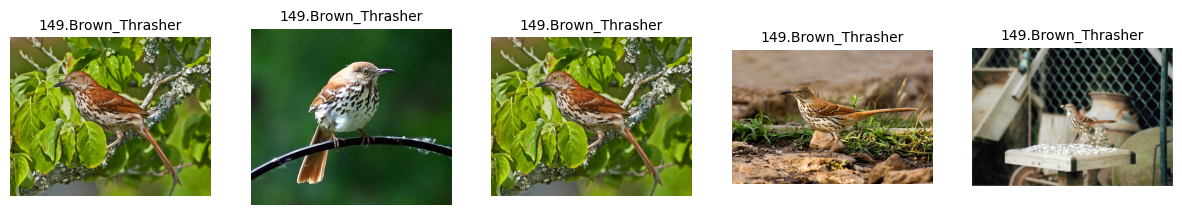

In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Dataset directory: the directory containing the "images" folder
data_dir = r'D:\DS_542_project\CUB_200_2011\images'

# List all classes (subfolders)
classes = os.listdir(data_dir)
print(f"Total {len(classes)} classes")

# Randomly select a class and display a few images from that class
random_class = random.choice(classes)
class_dir = os.path.join(data_dir, random_class)
image_files = os.listdir(class_dir)
print(f"There are {len(image_files)} images in class {random_class}")

# Randomly display 5 images
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax in axes:
    img_path = os.path.join(class_dir, random.choice(image_files))
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(random_class, fontsize=10)
    ax.axis('off')
plt.show()


In [2]:
import os
import shutil

# Base directory where the dataset is located
base_dir = r'D:\DS_542_project\CUB_200_2011'
images_dir = os.path.join(base_dir, 'images')
# Output directory to store the organized dataset
output_dir = os.path.join(base_dir, 'organized')
os.makedirs(output_dir, exist_ok=True)

# Define paths for the annotation files
images_file = os.path.join(base_dir, 'images.txt')
split_file = os.path.join(base_dir, 'train_test_split.txt')

# Create train and test directories
train_dir = os.path.join(output_dir, 'train')
test_dir = os.path.join(output_dir, 'test')
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Step 1: Read images.txt to build a mapping from image id to file path
id_to_path = {}
with open(images_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            image_id, rel_path = parts
            id_to_path[image_id] = rel_path

# Step 2: Read train_test_split.txt and copy images to the appropriate folder
with open(split_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            image_id, is_train = parts
            # Retrieve the relative file path from images.txt
            rel_path = id_to_path.get(image_id)
            if rel_path:
                # Extract the class name (the first part of the path, e.g., "001.Black_footed_Albatross")
                class_name = rel_path.split('/')[0]
                # Determine source file path
                src_path = os.path.join(images_dir, rel_path)
                # Determine destination directory based on the split
                if is_train == '1':
                    dst_dir = os.path.join(train_dir, class_name)
                else:
                    dst_dir = os.path.join(test_dir, class_name)
                # Create the class folder in the destination if it doesn't exist
                os.makedirs(dst_dir, exist_ok=True)
                # Copy the file
                shutil.copy(src_path, dst_dir)

print("Dataset organized into train and test folders!")


Dataset organized into train and test folders!


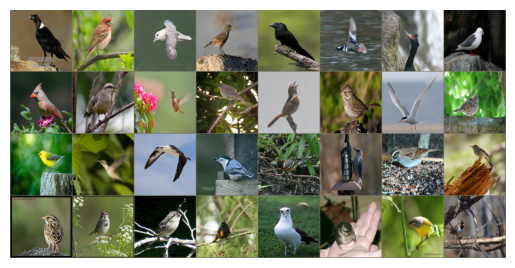

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Paths to the organized dataset
train_dir = r'D:\DS_542_project\CUB_200_2011\organized\train'
test_dir  = r'D:\DS_542_project\CUB_200_2011\organized\test'

# Define transforms for training and testing
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=transform_train)
test_dataset  = torchvision.datasets.ImageFolder(test_dir, transform=transform_test)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Optional: Visualize a batch of training images
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Function to unnormalize and show images
def imshow(img):
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img = img.clamp(0, 1)
    npimg = img.numpy().transpose((1, 2, 0))
    plt.imshow(npimg)
    plt.axis('off')
    plt.show()

# Display the images in a grid
imshow(torchvision.utils.make_grid(images))


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
from tqdm import tqdm

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define paths to your organized dataset
train_dir = r'D:\DS_542_project\CUB_200_2011\organized\train'
test_dir  = r'D:\DS_542_project\CUB_200_2011\organized\test'

# Define transforms for training and testing
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Create datasets using ImageFolder
train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=transform_train)
test_dataset  = torchvision.datasets.ImageFolder(test_dir, transform=transform_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Load a pretrained ResNet50 and modify the final layer for 200 classes
model = models.resnet50(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 200)
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10  # Set number of training epochs

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # Training loop
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

    # Evaluate on the test set after each epoch
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

print("Training complete!")


Using device: cuda


C:\Users\27435\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\27435\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 188/188 [00:18<00:00,  9.91it/s]


Epoch 1/10, Loss: 4.0108
Test Accuracy: 0.4147


Epoch 2/10: 100%|██████████| 188/188 [00:17<00:00, 10.52it/s]


Epoch 2/10, Loss: 1.9382
Test Accuracy: 0.6137


...

Epoch 8/10, Loss: 0.1098
Test Accuracy: 0.7209


Epoch 9/10: 100%|██████████| 188/188 [00:18<00:00, 10.33it/s]


Epoch 9/10, Loss: 0.0690
Test Accuracy: 0.7325


Epoch 10/10: 100%|██████████| 188/188 [00:17<00:00, 10.45it/s]


Epoch 10/10, Loss: 0.0503
Test Accuracy: 0.7344
Training complete!
